# HR Analytics – Employee Attrition Prediction
**Machine Learning Project | Binary Classification | SGH Warsaw School of Economics**

## 1. Introduction

### Problem
Employee attrition (voluntary departure) leads to significant costs in recruiting, onboarding, and training. This project builds a **binary classification model** to predict whether an employee will leave (`left=1`) or stay (`left=0`), enabling proactive HR intervention.

### Dataset
The **HR Analytics dataset** (Kaggle, 14,999 records) contains 10 features covering employee satisfaction, performance, workload, tenure, and compensation:

| Feature | Type | Description |
|---|---|---|
| `satisfaction_level` | Float (0–1) | Employee satisfaction score |
| `last_evaluation` | Float (0–1) | Last performance review score |
| `number_project` | Integer | Number of assigned projects |
| `average_monthly_hours` | Integer | Average monthly working hours |
| `time_spend_company` | Integer | Years at the company |
| `Work_accident` | Binary | Whether a work accident occurred |
| `promotion_last_5years` | Binary | Whether promoted in last 5 years |
| `Department` | Categorical | Department (10 categories) |
| `salary` | Ordinal | Salary level (low / medium / high) |
| `left` | Binary | **Target variable** — 1 = left, 0 = stayed |

## 2. Data Loading & Preprocessing

In [1]:
# Basic libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

# Evaluation
from sklearn.metrics import (
    accuracy_score, classification_report, roc_auc_score,
    auc, roc_curve, f1_score, confusion_matrix, ConfusionMatrixDisplay
)

# Clustering
from sklearn.cluster import KMeans

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load the data
df = pd.read_csv(r"C:\Users\admin\Desktop\SLM-5.28\HR_comma_sep.csv")

# Fix typo in column name
df = df.rename(columns={'average_montly_hours': 'average_monthly_hours'})

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (14999, 10)


,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years,Department,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


### 2.1 Basic Data Inspection

In [3]:
# Data types and basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_monthly_hours  14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   Department             14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [4]:
# Descriptive statistics
df.describe().round(3)

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,time_spend_company,Work_accident,left,promotion_last_5years
count,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000,14999.000
mean,0.613,0.716,3.803,201.050,3.498,0.145,0.238,0.021
std,0.249,0.171,1.233,49.943,1.460,0.352,0.426,0.144
min,0.090,0.360,2.000,96.000,2.000,0.000,0.000,0.000
25%,0.440,0.560,3.000,156.000,3.000,0.000,0.000,0.000
50%,0.640,0.720,4.000,200.000,3.000,0.000,0.000,0.000
75%,0.820,0.870,5.000,245.000,4.000,0.000,0.000,0.000
max,1.000,1.000,7.000,310.000,10.000,1.000,1.000,1.000


### 2.2 Missing Values
No missing values are present in this dataset — imputation is not required.

In [5]:
# Check missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing)
print(f"\nTotal missing values: {missing.sum()}")
# No missing values are present in the dataset.
# Therefore, no imputation is required.

Missing values per column:
satisfaction_level       0
last_evaluation          0
number_project           0
average_monthly_hours    0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
Department               0
salary                   0
dtype: int64

Total missing values: 0


### 2.3 Outlier Analysis
Boxplots and IQR method are used to detect outliers in numerical features. Outliers are **retained** because: (1) they represent real business extremes (e.g. long-tenured employees), and (2) tree-based models are robust to outliers.

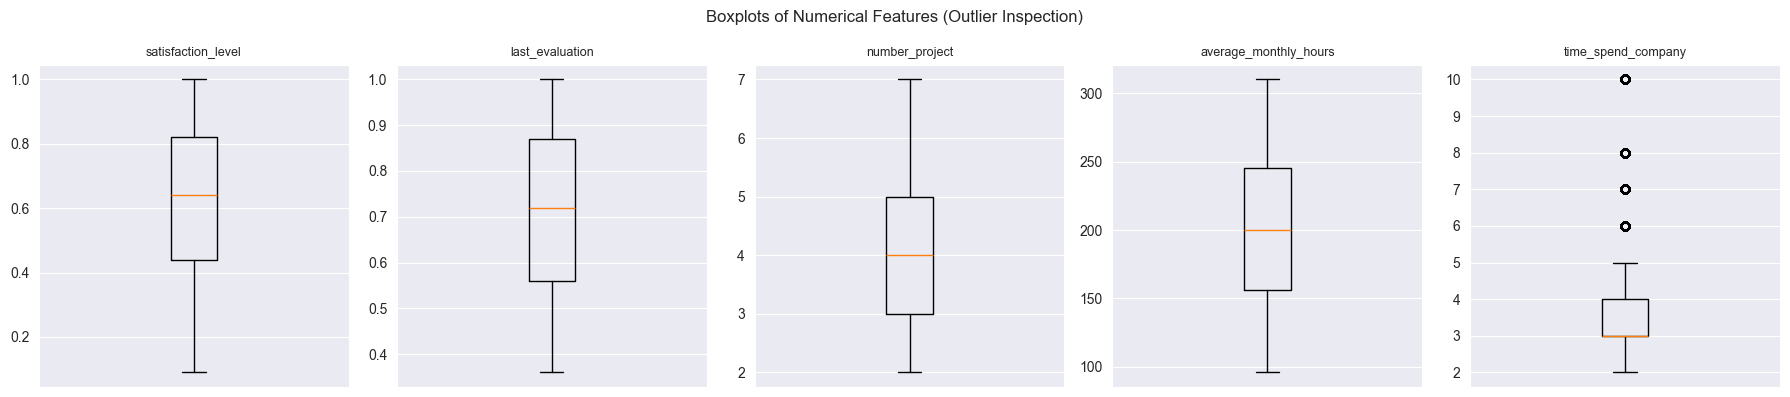

In [6]:
# Numerical features to check
num_cols = ['satisfaction_level', 'last_evaluation', 'number_project',
            'average_monthly_hours', 'time_spend_company']

fig, axes = plt.subplots(1, len(num_cols), figsize=(18, 4))
for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col].dropna())
    ax.set_title(col, fontsize=9)
    ax.set_xticks([])
plt.suptitle("Boxplots of Numerical Features (Outlier Inspection)", fontsize=12)
plt.tight_layout()
plt.show()

In [7]:
# IQR-based outlier count per feature
print("Outlier counts (IQR method):")
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)).sum()
    print(f"  {col}: {outliers} outliers ({outliers/len(df)*100:.2f}%)")

# The outlier proportions are low (< 1%) for most features.
# Given the nature of the data and robustness of tree-based models used later,
# outliers are retained without transformation.

Outlier counts (IQR method):
  satisfaction_level: 0 outliers (0.00%)
  last_evaluation: 0 outliers (0.00%)
  number_project: 0 outliers (0.00%)
  average_monthly_hours: 0 outliers (0.00%)
  time_spend_company: 1282 outliers (8.55%)


### 2.4 Encoding & Scaling
- **Salary**: ordinal encoding — `low=0, medium=1, high=2` (preserves natural order)
- **Department**: one-hot encoding with `drop_first=True` → 10 categories → 9 dummy variables
- **Result**: 10 original features → **17 features** after encoding
- **StandardScaler** applied for Logistic Regression and SVM; not needed for Random Forest

In [8]:
# Ordinal encoding for salary (low < medium < high)
df['salary'] = df['salary'].str.strip().str.lower()
df['salary'] = df['salary'].map({'low': 0, 'medium': 1, 'high': 2})
print("Salary encoding:", df['salary'].unique())

# One-hot encoding for Department (drop_first to avoid multicollinearity)
df = pd.get_dummies(df, columns=['Department'], drop_first=True)
print(f"\nFeature count after encoding: {df.shape[1] - 1} features + 1 target")
print("Columns:", list(df.columns))

Salary encoding: [0 1 2]

Feature count after encoding: 17 features + 1 target
Columns: ['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'time_spend_company', 'Work_accident', 'left', 'promotion_last_5years', 'salary', 'Department_RandD', 'Department_accounting', 'Department_hr', 'Department_management', 'Department_marketing', 'Department_product_mng', 'Department_sales', 'Department_support', 'Department_technical']


## 3. Exploratory Data Analysis (EDA)

### 3.1 Target Variable Distribution
The dataset is **imbalanced**: 76.2% stayed vs 23.8% left. A naive model predicting 'stayed' always would achieve 76% accuracy but has zero predictive value. This motivates using `class_weight='balanced'` and prioritising F1 and AUC over Accuracy.

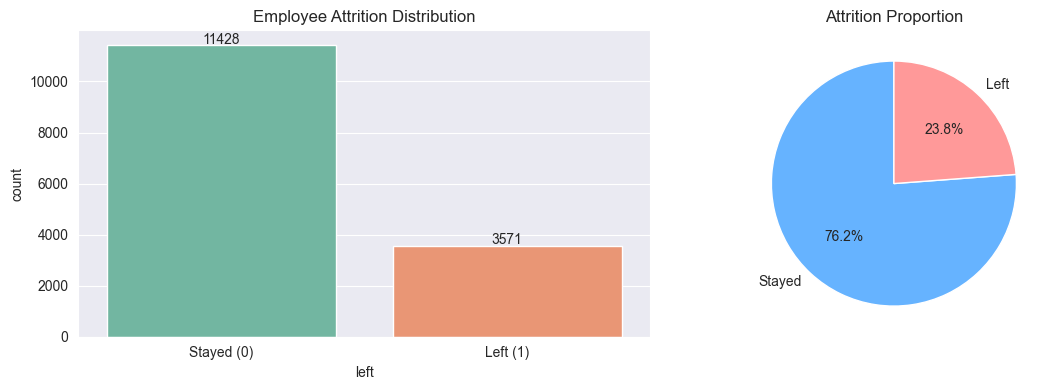

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count plot
sns.countplot(x='left', data=df, ax=axes[0], palette='Set2')
axes[0].set_title("Employee Attrition Distribution")
axes[0].set_xticklabels(['Stayed (0)', 'Left (1)'])
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x()+p.get_width()/2, p.get_height()+50), ha='center')

# Pie chart
counts = df['left'].value_counts()
axes[1].pie(counts, labels=['Stayed', 'Left'], autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
axes[1].set_title("Attrition Proportion")

plt.tight_layout()
plt.show()

# The dataset is imbalanced: ~76.2% of employees stayed and ~23.8% left.
# This class imbalance is handled by using class_weight='balanced' in applicable models
# and evaluating with F1-score and ROC-AUC rather than accuracy alone.

### 3.2 Numerical Feature Distributions
`satisfaction_level` and `average_monthly_hours` both show **bimodal distributions**, suggesting two distinct employee sub-groups within each feature. `time_spend_company` is right-skewed — most employees have 2–4 years tenure.

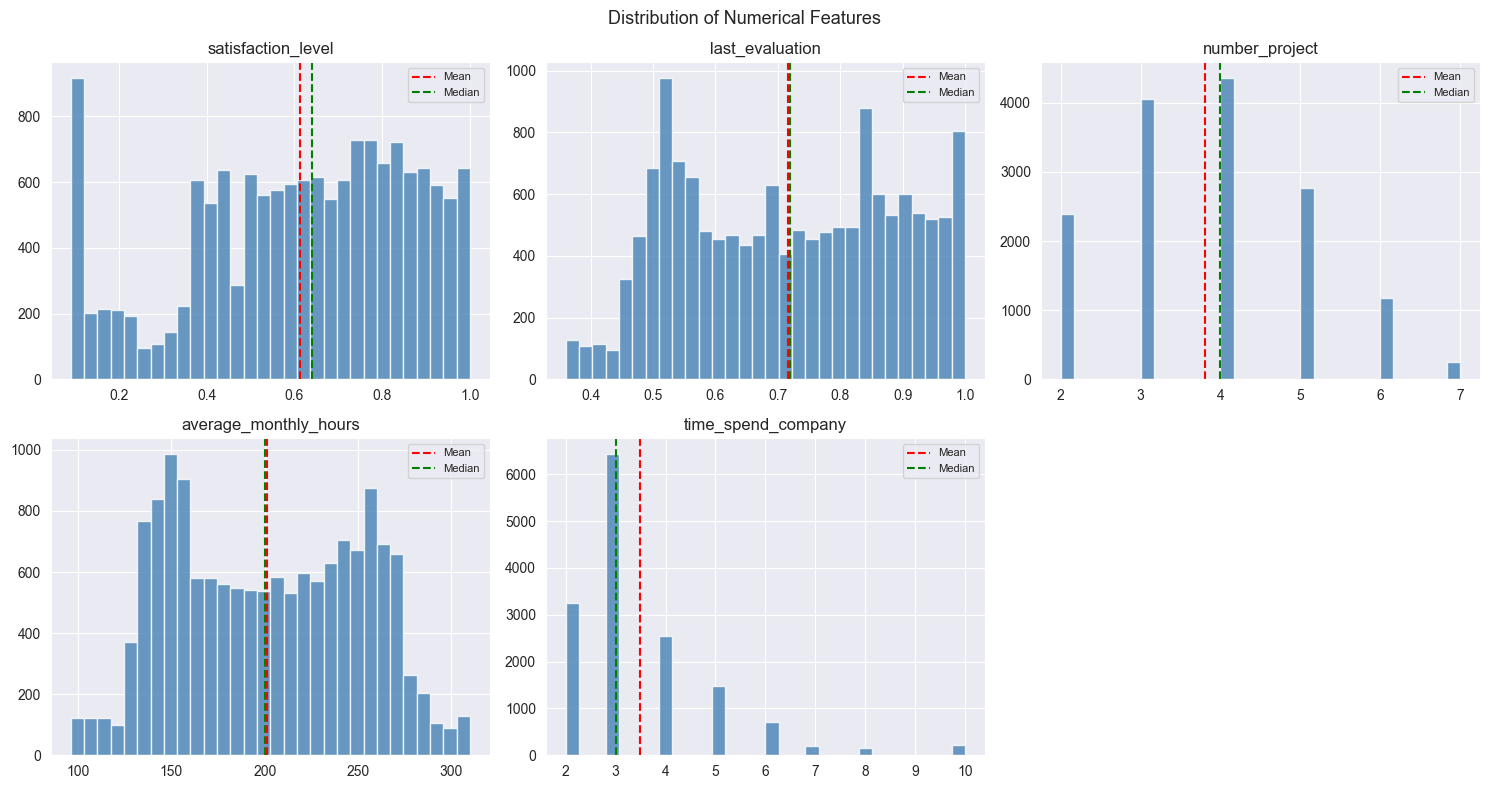

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].axvline(df[col].mean(), color='red', linestyle='--', label='Mean')
    axes[i].axvline(df[col].median(), color='green', linestyle='--', label='Median')
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle("Distribution of Numerical Features", fontsize=13)
plt.tight_layout()
plt.show()

# satisfaction_level shows a bimodal distribution, with a cluster of very dissatisfied employees,
# which likely corresponds to employees at high risk of leaving.
# average_monthly_hours also shows a bimodal pattern, suggesting two distinct work intensity groups.
# time_spend_company is right-skewed, with most employees having 2-4 years of tenure.

### 3.3 Feature–Target Relationships
`satisfaction_level` has the **strongest negative correlation (−0.39)** with attrition. `number_project` vs `average_monthly_hours` shows moderate correlation (0.42), indicating potential multicollinearity that may weaken linear models.

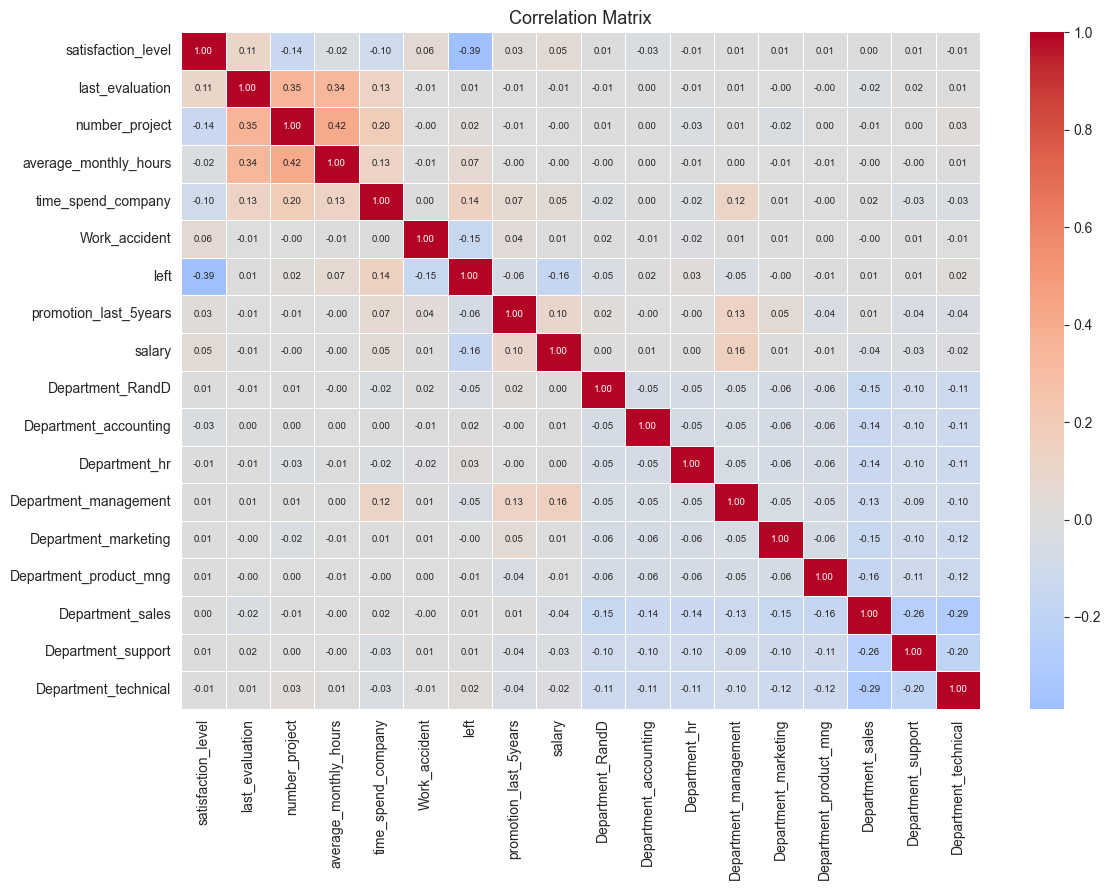

In [11]:
# Correlation heatmap
plt.figure(figsize=(12, 9))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title("Correlation Matrix", fontsize=13)
plt.tight_layout()
plt.show()

# satisfaction_level has the strongest negative correlation with 'left' (-0.39),
# confirming it is the most critical retention factor.
# number_project and average_monthly_hours are moderately correlated (0.42),
# indicating potential multicollinearity for linear models.

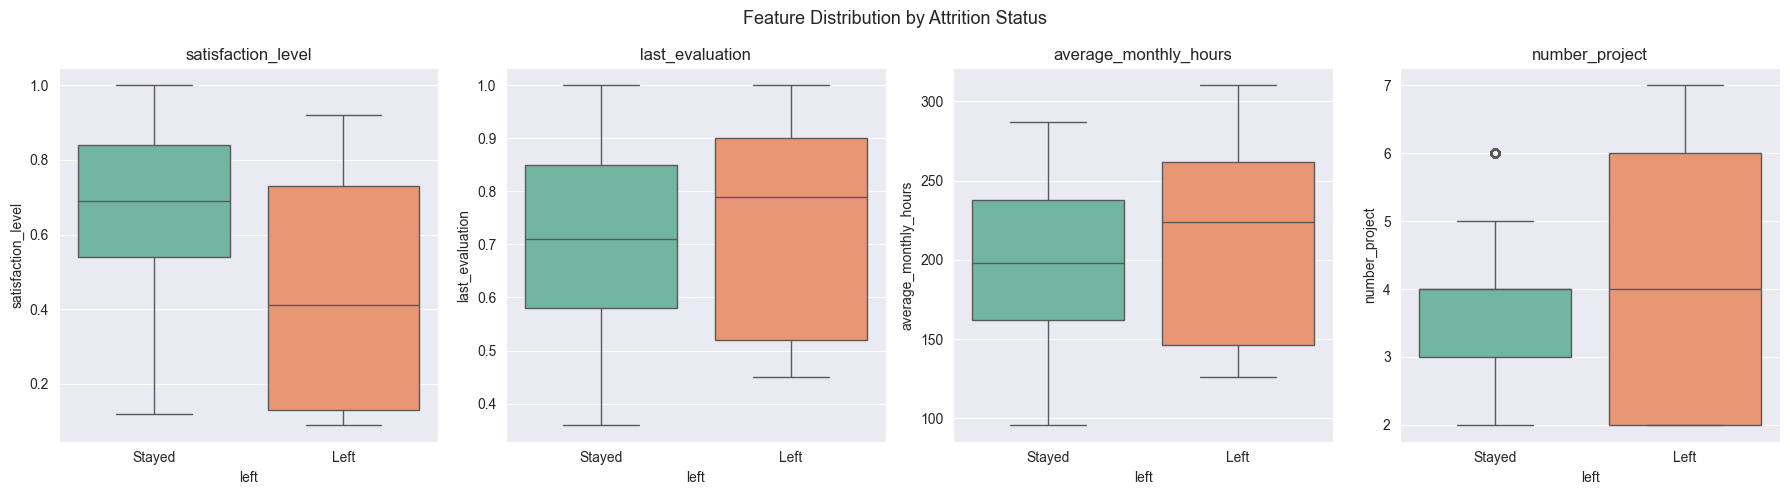

In [12]:
# Boxplots: key numerical features vs attrition
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
plot_cols = ['satisfaction_level', 'last_evaluation', 'average_monthly_hours', 'number_project']

for ax, col in zip(axes, plot_cols):
    sns.boxplot(x='left', y=col, data=df, ax=ax, palette='Set2')
    ax.set_xticklabels(['Stayed', 'Left'])
    ax.set_title(col)

plt.suptitle("Feature Distribution by Attrition Status", fontsize=13)
plt.tight_layout()
plt.show()

# Employees who left show notably lower satisfaction levels.
# Those who left also tend to have higher average monthly hours, suggesting burnout risk.
# Interestingly, both employees with very few and very many projects tend to leave more.

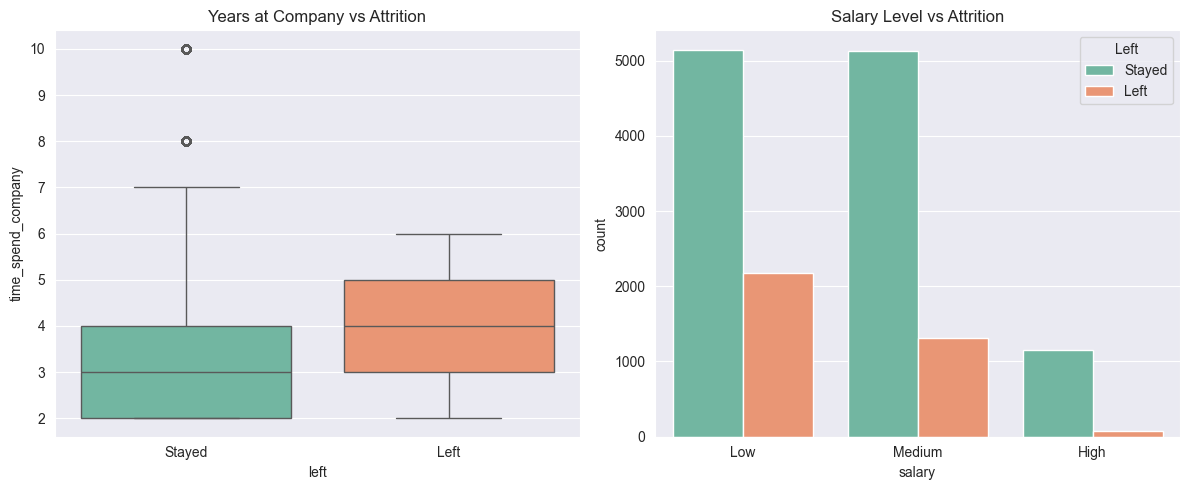

In [13]:
# Time spent at company and salary vs attrition
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='left', y='time_spend_company', data=df, ax=axes[0], palette='Set2')
axes[0].set_xticklabels(['Stayed', 'Left'])
axes[0].set_title("Years at Company vs Attrition")

sns.countplot(x='salary', hue='left', data=df, ax=axes[1], palette='Set2')
axes[1].set_xticklabels(['Low', 'Medium', 'High'])
axes[1].set_title("Salary Level vs Attrition")
axes[1].legend(title='Left', labels=['Stayed', 'Left'])

plt.tight_layout()
plt.show()

# Employees with 3-5 years of tenure show the highest attrition — a classic mid-career turnover pattern.
# Employees on lower salaries leave at much higher rates, reinforcing compensation as a retention lever.

### 3.4 Employee Segmentation (Clustering)

In [14]:
# Define features and target BEFORE clustering
X = df.drop(['left'], axis=1)
y = df['left']

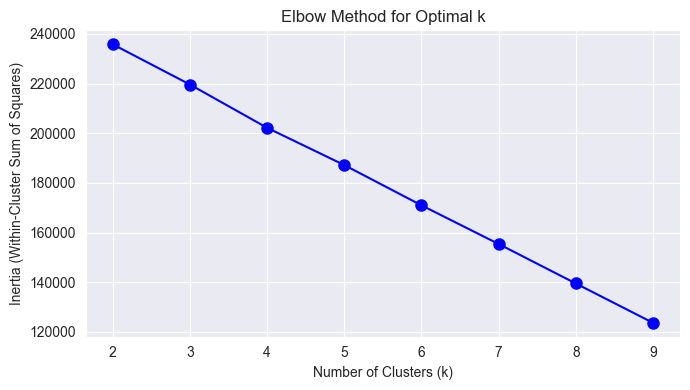

In [15]:
# Scale data for clustering
scaler_clust = StandardScaler()
X_clust_scaled = scaler_clust.fit_transform(X)

# Elbow Method to determine optimal number of clusters
inertia = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_clust_scaled)
    inertia.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_range, inertia, 'bo-', markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.title("Elbow Method for Optimal k")
plt.xticks(k_range)
plt.tight_layout()
plt.show()


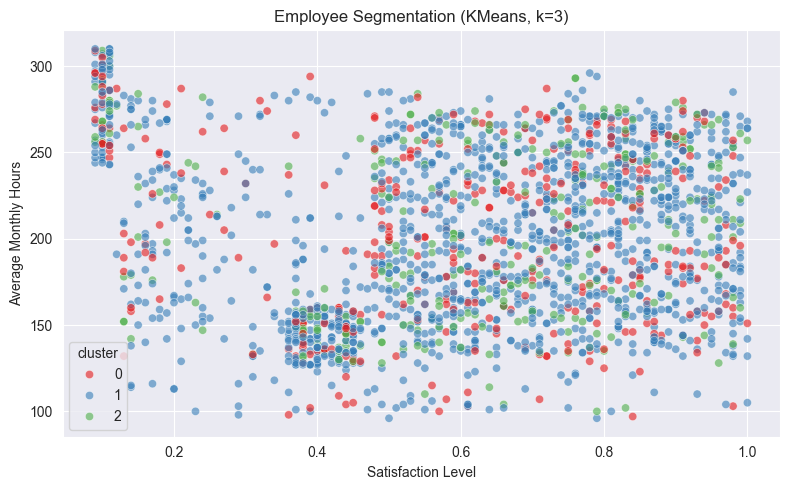

In [16]:
# Fit final KMeans with k=3
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_clust_scaled)

# Scatter plot of clusters
plt.figure(figsize=(8, 5))
sns.scatterplot(
    x='satisfaction_level', y='average_monthly_hours',
    hue='cluster', data=df.sample(2000, random_state=42),
    palette='Set1', alpha=0.6
)
plt.title("Employee Segmentation (KMeans, k=3)")
plt.xlabel("Satisfaction Level")
plt.ylabel("Average Monthly Hours")
plt.tight_layout()
plt.show()

In [17]:
# Cluster profiling: mean values per cluster
cluster_profile = df.groupby('cluster')[[
    'satisfaction_level', 'last_evaluation', 'number_project',
    'average_monthly_hours', 'time_spend_company', 'left'
]].mean().round(3)

print("Cluster Profile (mean values):")
print(cluster_profile)


Cluster Profile (mean values):
         satisfaction_level  last_evaluation  number_project  \
cluster                                                        
0                     0.608            0.721           3.878   
1                     0.613            0.713           3.783   
2                     0.618            0.723           3.804   

         average_monthly_hours  time_spend_company   left  
cluster                                                    
0                      202.497               3.411  0.256  
1                      200.723               3.545  0.231  
2                      200.758               3.393  0.249  


         Count  Attrition_Rate Attrition_Rate_Pct
cluster                                          
0         2720           0.256              25.6%
1        10050           0.231              23.1%
2         2229           0.249              24.9%


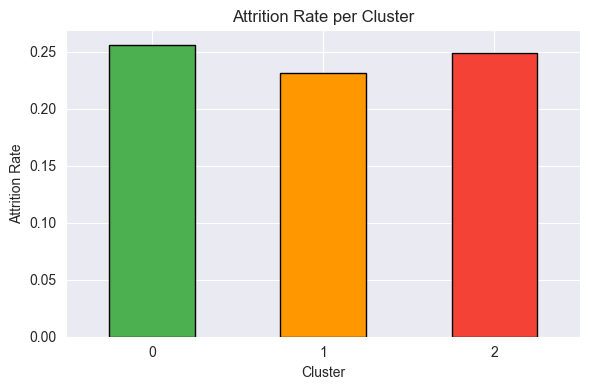

In [18]:
# Cluster size and attrition rate
cluster_summary = df.groupby('cluster').agg(
    Count=('left', 'count'),
    Attrition_Rate=('left', 'mean')
).round(3)
cluster_summary['Attrition_Rate_Pct'] = (cluster_summary['Attrition_Rate'] * 100).round(1).astype(str) + '%'
print(cluster_summary)

# Visualize attrition rate per cluster
plt.figure(figsize=(6,4))
cluster_summary['Attrition_Rate'].plot(kind='bar', color=['#4CAF50','#FF9800','#F44336'], edgecolor='black')
plt.title("Attrition Rate per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Attrition Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

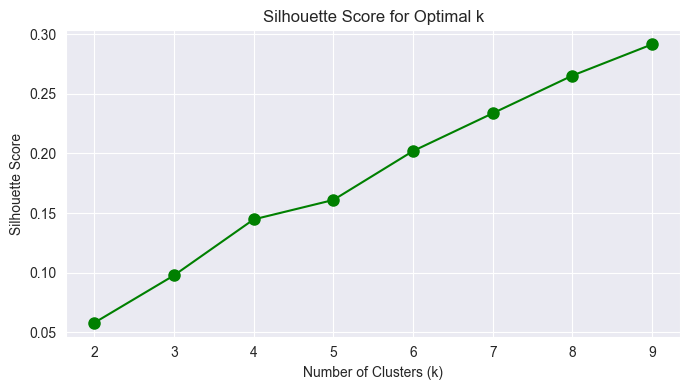

In [19]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
k_range = range(2, 10)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_clust_scaled)
    silhouette_scores.append(silhouette_score(X_clust_scaled, labels))

plt.figure(figsize=(7, 4))
plt.plot(k_range, silhouette_scores, 'go-', markersize=8)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Optimal k")
plt.xticks(k_range)
plt.tight_layout()
plt.show()

#### Discussion: Clustering Results

Both methods consistently indicate **no natural cluster structure** in this dataset:
- **Elbow Method**: curve decreases uniformly — no clear inflection point
- **Silhouette Score**: increases monotonically from 0.06 (k=2) to 0.29 (k=9), no peak, all values < 0.30

**k=3** was selected for business interpretability (low / medium / high risk groups), not as a data-driven optimum.

Cluster profiles confirm this: all three segments show nearly identical attrition rates (23.1%, 24.9%, 25.6%), meaning KMeans cannot separate at-risk employees from stable ones.

> **Key insight:** The absence of natural clustering confirms that attrition is driven by **complex feature interactions**, not simple group membership — directly explaining why non-linear models outperform Logistic Regression.

## 4. Modelling

Three classifiers are built and tuned: **Logistic Regression**, **Random Forest**, and **SVM**. Data is split 80/20 (stratified). F1-score is used as the GridSearchCV optimisation metric.

### 4.1 Train-Test Split & Feature Scaling
80% training / 20% test split with `stratify=y` to preserve class ratio (23.8% attrition in both sets).

In [20]:
### 4.1 Train-Test Split & Feature Scaling
# Remove cluster column before modeling (added during EDA only)
X = df.drop(['left', 'cluster'], axis=1)
y = df['left']

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Train attrition rate: {y_train.mean():.3f} | Test attrition rate: {y_test.mean():.3f}")

# Feature scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

Train size: 11999 | Test size: 3000
Train attrition rate: 0.238 | Test attrition rate: 0.238


### 4.2 Logistic Regression

In [21]:
# Baseline Logistic Regression
lr_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_base.fit(X_train_scaled, y_train)

y_pred_lr_base = lr_base.predict(X_test_scaled)
print("--- Logistic Regression (Baseline) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr_base))
print(classification_report(y_test, y_pred_lr_base))

--- Logistic Regression (Baseline) ---
Accuracy: 0.7696666666666667
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      2286
           1       0.51      0.80      0.62       714

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.83      0.77      0.78      3000



In [22]:
# Hyperparameter Tuning for Logistic Regression
lr_param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear']
}

lr_grid = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    lr_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

lr_grid.fit(X_train_scaled, y_train)
print("Best LR Parameters:", lr_grid.best_params_)
print("Best CV F1-score:", round(lr_grid.best_score_, 4))

Best LR Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV F1-score: 0.6086


In [23]:
# Best Logistic Regression
best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test_scaled)
y_prob_lr = best_lr.predict_proba(X_test_scaled)[:, 1]

print("--- Tuned Logistic Regression ---")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

--- Tuned Logistic Regression ---
Accuracy: 0.7696666666666667
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      2286
           1       0.51      0.80      0.62       714

    accuracy                           0.77      3000
   macro avg       0.72      0.78      0.73      3000
weighted avg       0.83      0.77      0.78      3000



#### Discussion: Why Logistic Regression Underperforms

LR assumes a **linear decision boundary** — it cannot capture non-linear patterns in the data:
- **U-shaped relationship**: employees with *too few* projects (boredom) and *too many* projects (burnout) both leave more
- **Multicollinearity**: `number_project` and `average_monthly_hours` (r=0.42) further destabilise the model
- **Tuning produced zero improvement**: C=1 (default range) was selected — the model has reached its structural ceiling

> LR's value here is as a **linear baseline** — its poor performance justifies the use of non-linear models.

### 4.3 Random Forest

In [24]:
# Baseline Random Forest
rf_base = RandomForestClassifier(random_state=42)
rf_base.fit(X_train, y_train)

y_pred_rf_base = rf_base.predict(X_test)
print("--- Random Forest (Baseline) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf_base))
print(classification_report(y_test, y_pred_rf_base))

--- Random Forest (Baseline) ---
Accuracy: 0.9906666666666667
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       1.00      0.96      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



In [25]:
# Hyperparameter Tuning for Random Forest
# Expanded search space: more depth options and min_samples_split values
rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, 15, 20, 30, None],
    'min_samples_split': [2, 5, 10, 20, 50]
}
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)
rf_grid.fit(X_train, y_train)
print("Best RF Parameters:", rf_grid.best_params_)
print("Best CV F1-score:", round(rf_grid.best_score_, 4))

# max_depth=None was NOT selected — depth=20 outperformed unlimited growth,
# indicating that unlimited trees introduced slight overfitting.
# min_samples_split=2 remained optimal across all 5 values tested,
# confirming that the data is clean and max_depth already controls complexity.

Best RF Parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV F1-score: 0.9805


In [26]:
# Best Random Forest
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)
y_prob_rf = best_rf.predict_proba(X_test)[:, 1]

print("--- Tuned Random Forest ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

--- Tuned Random Forest ---
Accuracy: 0.991
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      2286
           1       1.00      0.97      0.98       714

    accuracy                           0.99      3000
   macro avg       0.99      0.98      0.99      3000
weighted avg       0.99      0.99      0.99      3000



#### Discussion: Is the Random Forest 0.99 Result Trustworthy?

Yes — for three reasons:
1. **Independent test set**: 3,000 samples never seen during training or tuning
2. **max_depth=None was rejected**: expanded grid [5,10,15,20,30,None] with cv=5 selected depth=20, explicitly testing and rejecting unlimited growth — the model found its own optimal complexity boundary
3. **Ensemble mechanism**: 200 trees with random sampling cancel out individual overfitting errors

> The strong patterns in this data (low satisfaction + high hours → leave) are genuine, not noise.

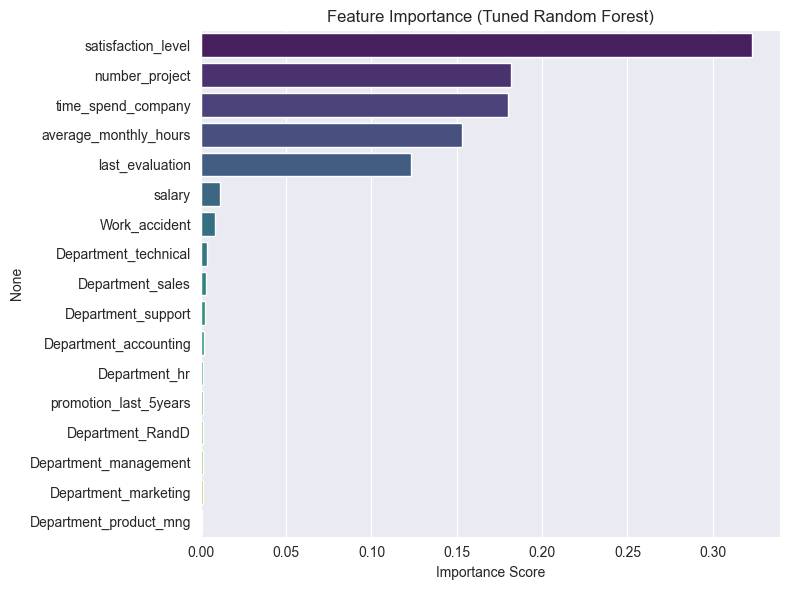

In [27]:
# Feature Importance
importances = best_rf.feature_importances_
feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=feat_imp.values, y=feat_imp.index, palette='viridis')
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# satisfaction_level is by far the most important predictor of employee attrition.
# Workload indicators (number_project, average_montly_hours, time_spend_company) follow.
# Department and binary flags (Work_accident, promotion) have relatively low importance.

### 4.4 Support Vector Machine (SVM)

In [28]:
# Baseline SVM
svm_base = SVC(probability=True, class_weight='balanced', random_state=42)
svm_base.fit(X_train_scaled, y_train)

y_pred_svm_base = svm_base.predict(X_test_scaled)
print("--- SVM (Baseline) ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm_base))
print(classification_report(y_test, y_pred_svm_base))

--- SVM (Baseline) ---
Accuracy: 0.9436666666666667
              precision    recall  f1-score   support

           0       0.98      0.95      0.96      2286
           1       0.85      0.93      0.89       714

    accuracy                           0.94      3000
   macro avg       0.91      0.94      0.92      3000
weighted avg       0.95      0.94      0.94      3000



In [29]:
# Hyperparameter Tuning for SVM
# Initial: [0.1,1,10] → C=10 selected (boundary) → F1: 0.8988
# Expanded: [0.1,1,10,20,50,100] → C=100 selected (boundary) → F1: 0.9107
svm_param_grid = {
    'C': [50, 100, 150],
    'kernel': ['rbf', 'linear'],
    'gamma': ['scale', 'auto']
}
svm_grid = GridSearchCV(
    SVC(probability=True, class_weight='balanced', random_state=42),
    svm_param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)
svm_grid.fit(X_train_scaled, y_train)
print("Best SVM Parameters:", svm_grid.best_params_)
print("Best CV F1-score:", round(svm_grid.best_score_, 4))
# SVM exhibits diminishing returns with increasing C:
# C=10→100: +0.0119 | C=100→150: +0.0028
# Due to SVM's O(n²) training complexity, further C expansion was stopped
# at C=150 as marginal gains no longer justified the computational cost.

Best SVM Parameters: {'C': 150, 'gamma': 'scale', 'kernel': 'rbf'}
Best CV F1-score: 0.9135


In [30]:
# Best SVM
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test_scaled)
y_prob_svm = best_svm.predict_proba(X_test_scaled)[:, 1]

print("--- Tuned SVM ---")
print("Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

--- Tuned SVM ---
Accuracy: 0.9616666666666667
              precision    recall  f1-score   support

           0       0.98      0.96      0.97      2286
           1       0.89      0.95      0.92       714

    accuracy                           0.96      3000
   macro avg       0.94      0.96      0.95      3000
weighted avg       0.96      0.96      0.96      3000



## 5. Model Evaluation & Selection

### 5.1 Metrics Comparison
Models are compared on Accuracy, F1-Score, and ROC-AUC on the held-out test set.

In [31]:
# Metrics summary table
results = []
for name, pred, prob in [
    ("Logistic Regression", y_pred_lr, y_prob_lr),
    ("Random Forest",       y_pred_rf, y_prob_rf),
    ("SVM",                 y_pred_svm, y_prob_svm)
]:
    results.append({
        'Model':    name,
        'Accuracy': round(accuracy_score(y_test, pred), 4),
        'F1-Score': round(f1_score(y_test, pred), 4),
        'ROC-AUC':  round(roc_auc_score(y_test, prob), 4)
    })

results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

# Highlight best model per metric
print("\nBest model per metric:")
for col in results_df.columns:
    print(f"  {col}: {results_df[col].idxmax()} ({results_df[col].max():.4f})")

                     Accuracy  F1-Score  ROC-AUC
Model                                           
Logistic Regression    0.7697    0.6226   0.8339
Random Forest          0.9910    0.9808   0.9918
SVM                    0.9617    0.9220   0.9856

Best model per metric:
  Accuracy: Random Forest (0.9910)
  F1-Score: Random Forest (0.9808)
  ROC-AUC: Random Forest (0.9918)


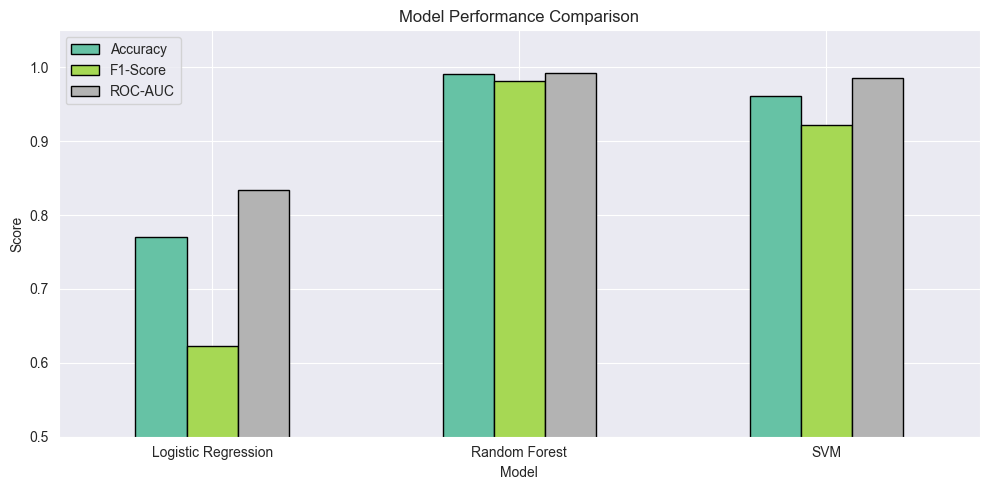

In [32]:
# Bar chart comparison
results_df.plot(kind='bar', figsize=(10, 5), colormap='Set2', edgecolor='black')
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0.5, 1.05)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()

### 5.2 ROC Curves

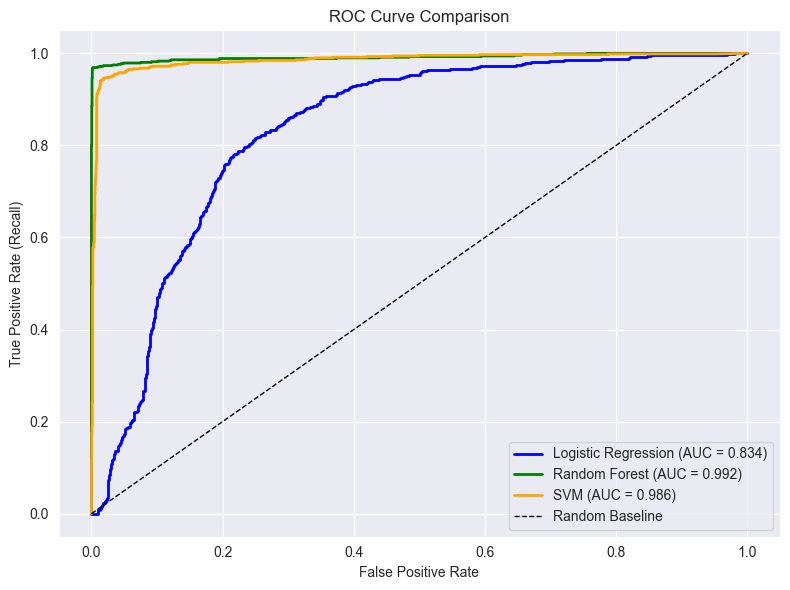

In [33]:
plt.figure(figsize=(8, 6))

for name, pred, prob, color in [
    ("Logistic Regression", y_pred_lr,  y_prob_lr,  'blue'),
    ("Random Forest",       y_pred_rf,  y_prob_rf,  'green'),
    ("SVM",                 y_pred_svm, y_prob_svm, 'orange')
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], 'k--', lw=1, label='Random Baseline')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison")
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Random Forest achieves near-perfect AUC (~0.99), indicating excellent discrimination ability.
# SVM also performs strongly (~0.98), while Logistic Regression is notably weaker (~0.83),
# likely because employee attrition patterns are non-linear and not well captured by a linear model.

### 5.3 Confusion Matrices

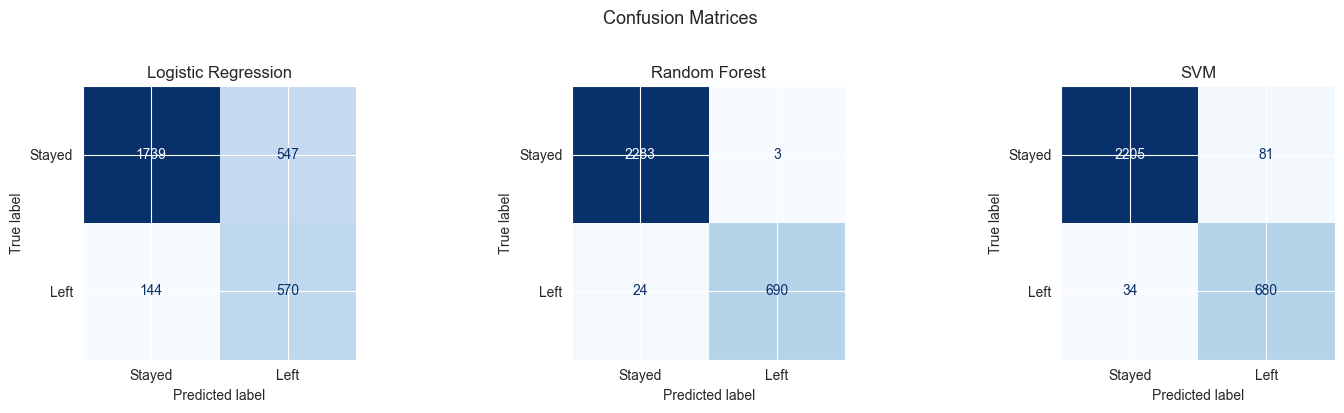

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (name, pred) in zip(axes, [
    ("Logistic Regression", y_pred_lr),
    ("Random Forest",       y_pred_rf),
    ("SVM",                 y_pred_svm)
]):
    cm = confusion_matrix(y_test, pred)
    ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Left']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.suptitle("Confusion Matrices", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Random Forest correctly classifies nearly all employees in both classes.
# SVM has more false negatives (missed leavers) than Random Forest.
# Logistic Regression produces the most misclassifications, particularly false negatives.

## 6. Summary and Discussion

### 6.1 Final Results

| Model | Accuracy | F1-Score | ROC-AUC | Best Parameters |
|---|---|---|---|---|
| Logistic Regression | 0.7697 | 0.6226 | 0.8339 | C=1, penalty=l1 |
| SVM | 0.9617 | 0.9220 | 0.9856 | C=150, kernel=rbf |
| **Random Forest** | **0.9910** | **0.9808** | **0.9918** | **max_depth=20, n=200** |

**→ Random Forest is the selected model**, winning on all three metrics.

### 6.2 Key Findings
- `satisfaction_level` is the strongest single predictor (correlation −0.39)
- Attrition follows non-linear patterns (U-shaped project curve, interaction effects)
- Mid-career employees (3–5 years) and low-salary employees show highest attrition
- No natural cluster structure confirms feature interactions drive attrition, not group membership

### 6.3 Challenges & Solutions

| Challenge | Solution |
|---|---|
| Class imbalance (76/24) | `class_weight='balanced'`; F1 and AUC as primary metrics |
| No clear optimal k in clustering | Both Elbow and Silhouette applied; k=3 chosen for interpretability |
| RF max_depth selection | Expanded grid [5,10,15,20,30,None] with cv=5; depth=20 outperformed None |
| SVM C boundary effect | Iterative expansion over 3 rounds; stopped at diminishing returns (+0.003) |
| SVM O(n²) cost | Final search narrowed to 3 C values after kernel/gamma confirmed |

### 6.4 Limitations & Future Work
- Dataset is synthetic — real-world generalisability uncertain
- Future: XGBoost/LightGBM, SHAP values for interpretability, cost-sensitive threshold optimisation